In [1]:
##pip install -U diffusers transformers accelerate

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V6.0_B1_noVAE/snapshots/9a857a696b9aabbf509073e0aa55ec8200b6ef7d/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V6.0_B1_noVAE/snapshots/9a857a696b9aabbf509073e0aa55ec8200b6ef7d/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (82 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic , shallow depth of field .']


  0%|          | 0/35 [00:00<?, ?it/s]

Saved to server: final_portrait_seed_101.png


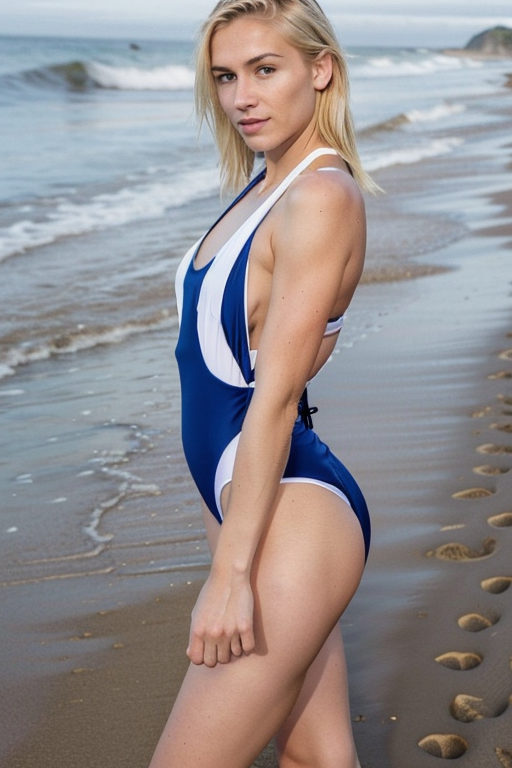

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic , shallow depth of field .']


  0%|          | 0/35 [00:00<?, ?it/s]

Saved to server: final_portrait_seed_202.png


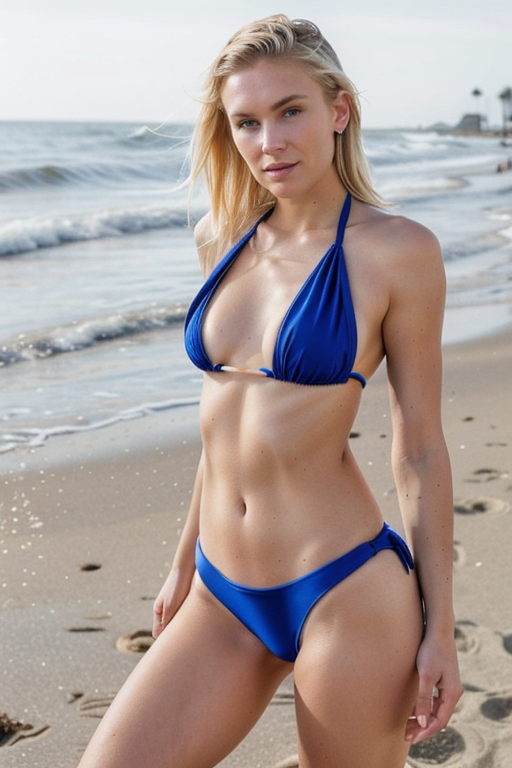

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic , shallow depth of field .']


  0%|          | 0/35 [00:00<?, ?it/s]

Saved to server: final_portrait_seed_303.png


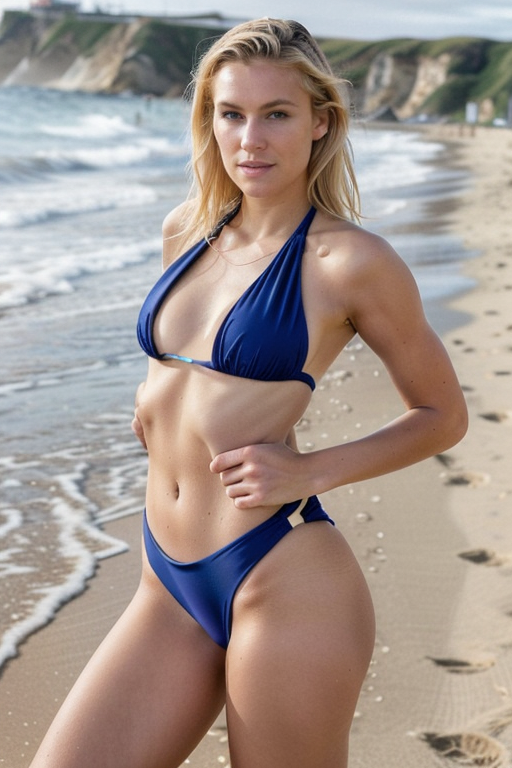


--- All images generated! Bundling for download ---
Archive created: generated_images.zip. Downloading to your PC now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import io
import gc
import os
import torch
import zipfile
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler, AutoencoderKL
from PIL import Image
from IPython.display import display
from google.colab import files

# 1. Configuration
model_id = "SG161222/Realistic_Vision_V6.0_B1_noVAE"
vae_id = "stabilityai/sd-vae-ft-mse"

# 2. Load Pipeline and VAE securely
vae = AutoencoderKL.from_pretrained(vae_id, torch_dtype=torch.float16)

pipe = DiffusionPipeline.from_pretrained(
    model_id,
    vae=vae,
    torch_dtype=torch.float16
)

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

# 3. Disable safety checker & optimize VRAM
pipe.safety_checker = None
pipe.enable_attention_slicing()
if torch.cuda.is_available():
    pipe.enable_model_cpu_offload()

# 4. Prompts
prompt = (
    "A candid, raw 35mm photo capturing a nordic woman, "
    "A realistic portrait of a trim, athletic woman, female proportions, blue eyes, blonde hair, and tall legs."
    "navigating sand, ocean beach environment. "
    "The focus is sharp on the bikini spandex swimsuit textures, "
    "Cinematic ambient lighting, highly detailed fabric, visible skin texture, "
    "8k dslr, realistic film grain, hyperrealistic, shallow depth of field."
)

negative_prompt = (
    "3d render, cgi, digital painting, painting, illustration, cartoon, "
    "bad anatomy, mutated, deformed eyes, extra limbs, crossed eyes, "
    "melting face, smooth skin, airbrushed, plastic skin, doll, low quality, "
    "worst quality, glossy reflection on visor covering face, cartoonish"
)

seeds = [101, 202, 303]
generated_files = []

# 5. Run inference loop
for current_seed in seeds:
    generator = torch.Generator(device="cuda" if torch.cuda.is_available() else "cpu").manual_seed(current_seed)

    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        height=768,
        width=512,
        num_inference_steps=35,
        guidance_scale=8.5,
        generator=generator
    ).images[0]

    img_byte_arr = io.BytesIO()
    image.save(img_byte_arr, format='PNG')
    img_bytes = img_byte_arr.getvalue()

    # Save output to Colab server disk
    output_filename = f"final_portrait_seed_{current_seed}.png"
    image.save(output_filename)
    generated_files.append(output_filename)
    print(f"Saved to server: {output_filename}")

    display(image)

    # Clean memory
    del image, img_byte_arr, img_bytes
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print("\n--- All images generated! Bundling for download ---")

# 6. Create ZIP and download once at the end
zip_filename = "generated_images.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in generated_files:
        if os.path.exists(file):
            zipf.write(file)

print(f"Archive created: {zip_filename}. Downloading to your PC now...")

try:
    files.download(zip_filename)
except Exception as e:
    print(f"Download failed: {e}")
    print("Check your browser's pop-up blocker or cookie settings for Google Colab.")